In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import sys
from tqdm.auto import tqdm
from time_series import create_time_series
sys.path.insert(0, os.path.abspath("../fsrs-optimizer/src/fsrs_optimizer/"))
import fsrs_optimizer
import numpy as np

tqdm.pandas()

/home/luc/Programming/forks/fatigue-graph/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Review count: User id
# Median: 8798
# Most: 6810

USER_ID = 2
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("user_id", "=", USER_ID), ("rating", "in", [1, 2, 3, 4])], columns=["card_id", "day_offset", "rating", "elapsed_days", "duration"] 
)
df.size

348825

In [3]:
df.describe()

,card_id,day_offset,rating,elapsed_days,duration
count,69765.00000,69765.000000,69765.000000,69765.000000,69765.000000
mean,4508.86724,2641.374715,2.641582,53.913897,9474.496954
std,2863.01216,710.539625,0.959897,146.712739,10032.081677
min,0.00000,0.000000,1.000000,-1.000000,0.000000
25%,1764.00000,2417.000000,2.000000,0.000000,3384.000000
50%,4581.00000,2697.000000,3.000000,2.000000,5669.000000
75%,6924.00000,3096.000000,3.000000,33.000000,11014.000000
max,9578.00000,3634.000000,4.000000,2907.000000,60000.000000


In [4]:
df[df["card_id"] == 230]

,card_id,day_offset,rating,elapsed_days,duration
8761,230,2986,3,-1,2598
8762,230,2987,3,1,2673
8763,230,2987,4,0,1908
8764,230,2993,3,6,1704
8765,230,3006,3,13,2804
8766,230,3098,3,92,2373
8767,230,3217,3,119,3355
8768,230,3317,3,100,3004
8769,230,3566,3,249,3290


In [5]:
df["prior_reviews"] = df.groupby("day_offset").cumcount()

In [6]:
print("creating time series")
df["delta_t"] = df["elapsed_days"]
df: pd.DataFrame = create_time_series(df)
print("training")
trainer = fsrs_optimizer.Trainer(df, df, fsrs_optimizer.DEFAULT_PARAMETER)
w = trainer.train()

creating time series
training


train:  23%|██▎       | 9728/43030 [00:00<00:01, 21312.66it/s]

iteration: 4096
w: [0.3991, 1.2418, 3.244, 15.648, 7.2829, 0.4407, 1.5248, 0.001, 1.4459, 0.2263, 0.9202, 1.9338, 0.1479, 0.3039, 2.238, 0.2213, 2.9198, 0.5679, 0.6332]
iteration: 8192
w: [0.402, 1.2341, 3.3071, 15.681, 7.3193, 0.3937, 1.5702, 0.001, 1.3983, 0.2951, 0.8718, 1.9513, 0.1349, 0.3287, 2.2242, 0.1894, 2.8676, 0.5794, 0.6811]


train:  30%|██▉       | 12800/43030 [00:00<00:01, 22909.41it/s]

iteration: 12288
w: [0.3723, 1.2211, 3.3731, 15.707, 7.3286, 0.3802, 1.6073, 0.001, 1.3823, 0.3235, 0.8559, 1.9678, 0.1172, 0.3494, 2.2136, 0.1851, 2.8437, 0.5699, 0.7039]


...

iteration: 24576
w: [0.3377, 1.2929, 3.4549, 15.7503, 7.346, 0.3427, 1.6399, 0.001, 1.3648, 0.3866, 0.8398, 1.9598, 0.1121, 0.3479, 2.2015, 0.1616, 2.7926, 0.4925, 0.6985]
iteration: 28672
w: [0.3213, 1.3006, 3.4659, 15.7597, 7.3416, 0.3455, 1.6504, 0.001, 1.3672, 0.3962, 0.8423, 1.9616, 0.1097, 0.3492, 2.2009, 0.1713, 2.7935, 0.4899, 0.7001]


train:  87%|████████▋ | 37398/43030 [00:01<00:00, 28567.53it/s]

iteration: 32768
w: [0.3226, 1.306, 3.4738, 15.7574, 7.3402, 0.3462, 1.6575, 0.001, 1.3681, 0.4029, 0.8435, 1.9581, 0.1134, 0.3462, 2.1962, 0.1691, 2.7965, 0.4885, 0.7052]
iteration: 36864
w: [0.3253, 1.3102, 3.4781, 15.7554, 7.3424, 0.3444, 1.6592, 0.0015, 1.3668, 0.4067, 0.8423, 1.9588, 0.1117, 0.347, 2.1934, 0.165, 2.7965, 0.4855, 0.707]


train: 100%|██████████| 43030/43030 [00:02<00:00, 20772.45it/s]


iteration: 40960
w: [0.3258, 1.312, 3.4803, 15.7559, 7.3423, 0.3444, 1.6594, 0.0011, 1.3669, 0.4071, 0.8423, 1.9591, 0.1112, 0.3472, 2.1941, 0.1645, 2.7972, 0.4853, 0.7074]


In [7]:
import math

DECAY = -0.5
FACTOR = 0.9 ** (1 / DECAY) - 1

def power_forgetting_curve(t, s):
    return (1 + FACTOR * t / s) ** DECAY

def stability_after_success(s, r, d, rating):
    hard_penalty = w[15] if rating == 2 else 1
    easy_bonus = w[16] if rating == 4 else 1
    return max(
        0.01,
        s * (
            1
            + math.exp(w[8])
            * (11 - d)
            * (s ** -w[9])
            * (math.exp((1 - r) * w[10]) - 1)
            * hard_penalty
            * easy_bonus
        )
    )

def stability_after_failure(s, r, d):
    return max(
        0.01,
        min(
            w[11]
            * (d ** -w[12])
            * ((s + 1) ** w[13] - 1)
            * math.exp((1 - r) * w[14]),
            s / math.exp(w[17] * w[18])
        )
    )

def stability_short_term(s, init_rating=None):
    if init_rating is not None:
        rating_offset = fsrs_optimizer.DEFAULT_FIRST_RATING_OFFSETS[init_rating - 1]
        session_len = fsrs_optimizer.DEFAULT_FIRST_SESSION_LENS[init_rating - 1]
    else:
        rating_offset = fsrs_optimizer.DEFAULT_FORGET_RATING_OFFSET
        session_len = fsrs_optimizer.DEFAULT_FORGET_SESSION_LEN
    
    new_s = s * math.exp(
        w[17] * (rating_offset + session_len * w[18])
    )
    return new_s

def init_d(rating):
    return w[4] - math.exp(w[5] * (rating - 1)) + 1

def init_d_with_short_term(rating):
    rating_offset = fsrs_optimizer.DEFAULT_FIRST_RATING_OFFSETS[rating - 1]
    new_d = init_d(rating) - w[6] * rating_offset
    return max(1, min(new_d, 10))

def linear_damping(delta_d, old_d):
    return delta_d * (10 - old_d) / 9

def mean_reversion(init, current):
    return w[7] * init + (1 - w[7]) * current

def next_d(d, rating):
    delta_d = -w[6] * (rating - 3)
    new_d = d + linear_damping(delta_d, d)
    new_d = mean_reversion(init_d(4), new_d)
    return max(1, min(new_d, 10))


In [8]:
def memory_state(df):
    t_history = [int(t) for t in df["t_history"].split(",")]
    r_history = [int(r) for r in df["r_history"].split(",")]
    difficulty = None
    stability = None
    retrievability = 1e-10
    for delta_t, rating in zip(t_history, r_history):
        if stability is None:  # New card
            difficulty = init_d_with_short_term(rating)
            stability = stability_short_term(w[rating - 1], init_rating=rating)
        else:
            retrievability = power_forgetting_curve(delta_t, stability)
            if rating > 1:
                stability = stability_after_success(
                    stability, retrievability, difficulty, rating
                )
            else:
                stability = stability_after_failure(stability, retrievability, difficulty)
                stability = stability_short_term(stability)
            difficulty = next_d(difficulty, rating)
            if rating == 1:
                difficulty -= (w[6] * fsrs_optimizer.DEFAULT_FORGET_RATING_OFFSET)
                difficulty = min(max(difficulty, 1), 10)

    return stability, difficulty, retrievability


df["s"], df["d"], df["r"] = zip(*df.progress_apply(memory_state, axis=1))

100%|██████████| 43080/43080 [00:00<00:00, 50157.35it/s]


In [9]:
df["loss"] = df.apply(lambda df: (df["y"] - df["r"]) ** 2, axis=1)
# df["duration"] = (df["duration"] / 1000).round(0) Ok what the hell is wrong with my past self?

# Ok this is broken for now \\/

Average Very Young cards per day 14696.0


<Figure size 640x480 with 0 Axes>

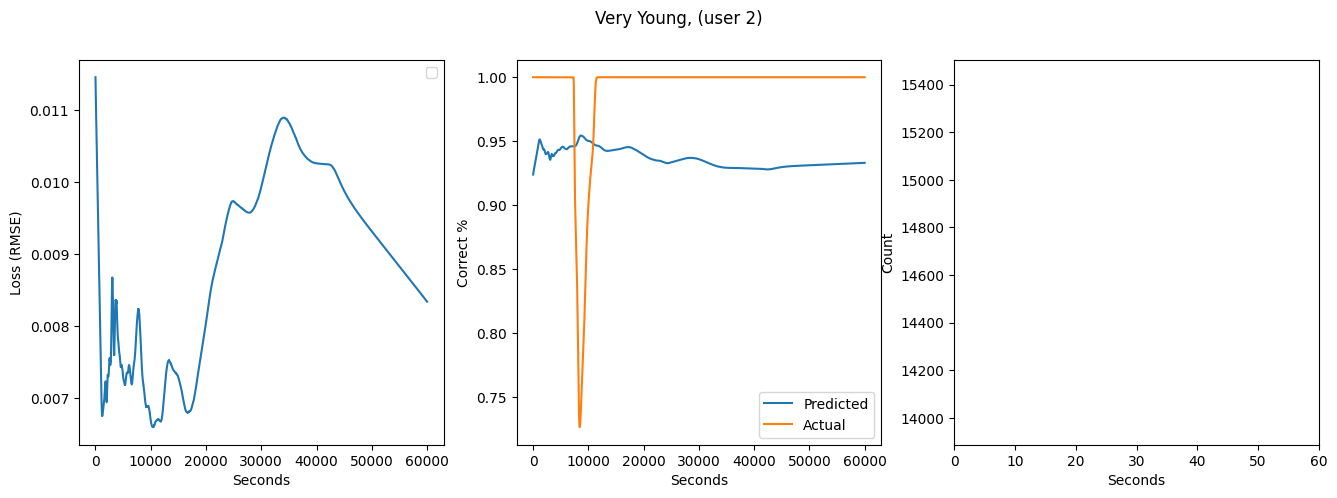

Average Young cards per day 22151.0


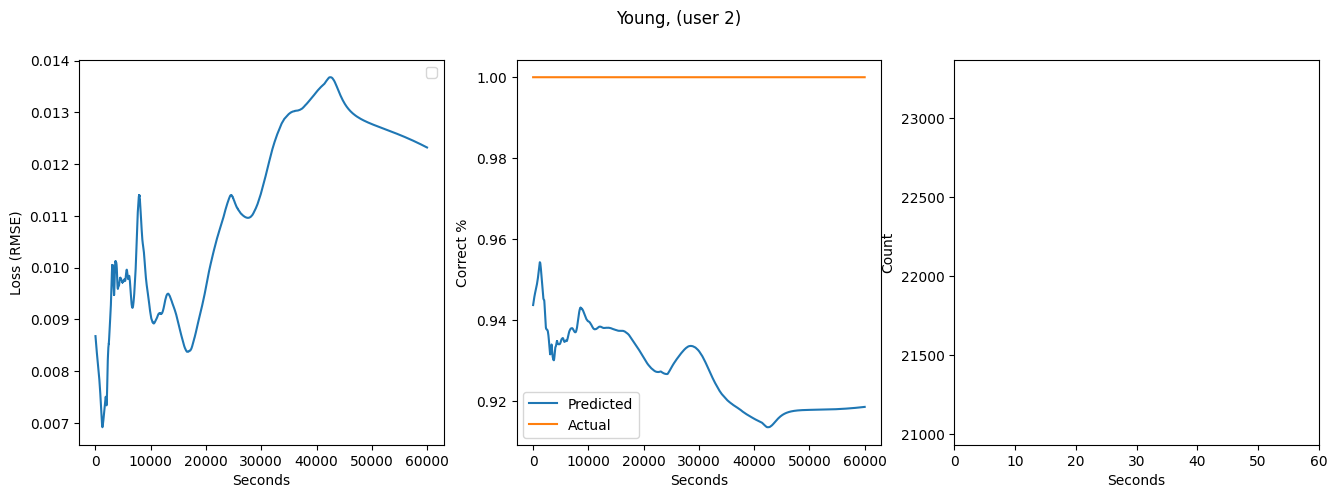

Average Mature cards per day 15841.0


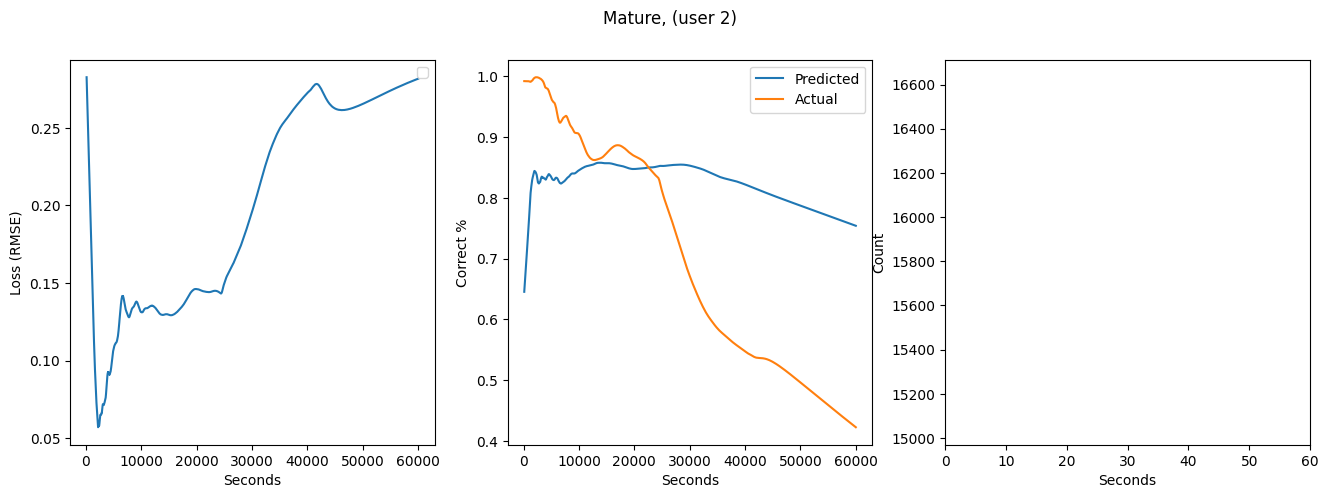

Average All cards per day 37992.0


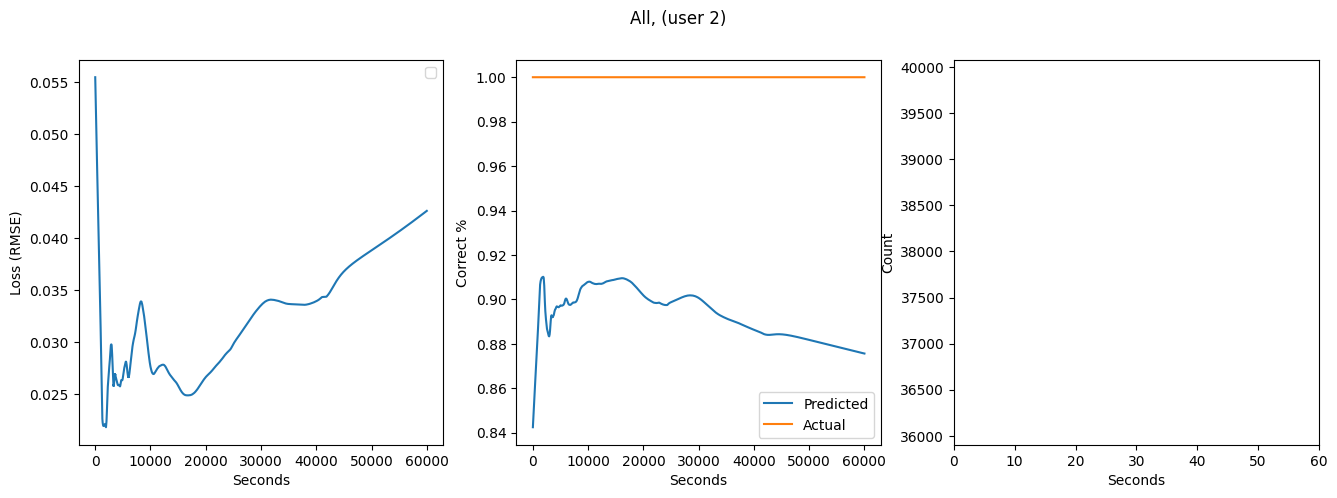

In [10]:
from utils import moving_average

plt.clf()
categories = [
    #("Learn", -1, 1), 
    ("Very Young", 0, 4), 
    ("Young", 0, 21), 
    ("Mature", 21, 1e20),
    ("All", -1, 1e20)
]

for name, lower, upper in categories:
    df_filtered = df[(df["elapsed_days"] > lower) & (df["elapsed_days"] <= upper) & (df["r"] > 1e-9)]

    print(f"Average {name} cards per day {df_filtered['card_id'].count().mean()}")
    loss = df_filtered["loss"].mean() ** 0.5
    loss = moving_average(df_filtered["duration"], df_filtered["loss"])

    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(f"{name}, (user {USER_ID})")
    ax1 = fig.add_subplot(131)
    xlim = 60

    ax1.set_xlabel('Seconds')
    ax1.set_ylabel('Loss (RMSE)')
    ax1.plot(*loss)
    ax1.legend()


    ax2 = fig.add_subplot(132)

    ax2.plot(*moving_average(df_filtered["duration"], df_filtered["r"]), label="Predicted")
    ax2.plot(*moving_average(df_filtered["duration"], df_filtered["y"]), label="Actual")
    ax2.set_xlabel('Seconds')
    ax2.set_ylabel('Correct %')
    ax2.legend()

    ax3 = fig.add_subplot(133)

    ax3.plot(df_filtered["r"].count())
    ax3.set_xlabel('Seconds')
    ax3.set_ylabel('Count') # Number of days that the user had that many reviews or more
    ax3.set_xlim(0, xlim)

    plt.show()


In [11]:
df_filtered = df[(df["elapsed_days"] > 0) & (df["r"] > 0.7)]
df_filtered.sort_values("elapsed_days", inplace=True)

/tmp/ipykernel_105714/3107958746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values("elapsed_days", inplace=True)


# Current residual

The average per rating - the actual duration

In [12]:
groups = df_filtered.groupby("rating")["duration"].median()

df_filtered["review_average"] = df_filtered["duration"] - df_filtered["rating"].map(groups)

current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["review_average"]).mean())

current_residual, groups

/tmp/ipykernel_105714/1618790563.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["review_average"] = df_filtered["duration"] - df_filtered["rating"].map(groups)
/tmp/ipykernel_105714/1618790563.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["review_average"]).mean())


(rating
 1.0    7831.829314
 2.0    7776.656298
 3.0    5402.051326
 4.0    2746.695724
 dtype: float64,
 rating
 1.0    8583.0
 2.0    8290.0
 3.0    4966.5
 4.0    3709.0
 Name: duration, dtype: float64)

In [ ]:
POLYFIT_DEGREE = 1
def duration_plot(df, x_col, axes, label, current):
    df.sort_values(x_col, inplace=True)
    x = df[x_col]
    y = df["duration"]

    # groups = df.groupby(x_col)["duration"].mean()
    c = np.polyfit(x, y, POLYFIT_DEGREE)
    axes.plot(x, np.polyval(c, x), color="orange")
    axes.scatter(x, y, s=0.1)

    axes.set_title(f"{label} residual:{float(residual):.2f} improvement:{float(current-residual):.2f}")
    axes.set_xlabel(x_col)
    axes.set_ylabel("duration (ms)")

def duration_plot_ratings(x, df = df_filtered):
    fig = plt.figure(figsize=(12, 12))
    for rating in range(1, 5):
        duration_plot(df[df["rating"] == rating], x, fig.add_subplot(2, 2, rating), f"{rating=}", current_residual[rating])

/tmp/ipykernel_105714/246576057.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(x_col, inplace=True)


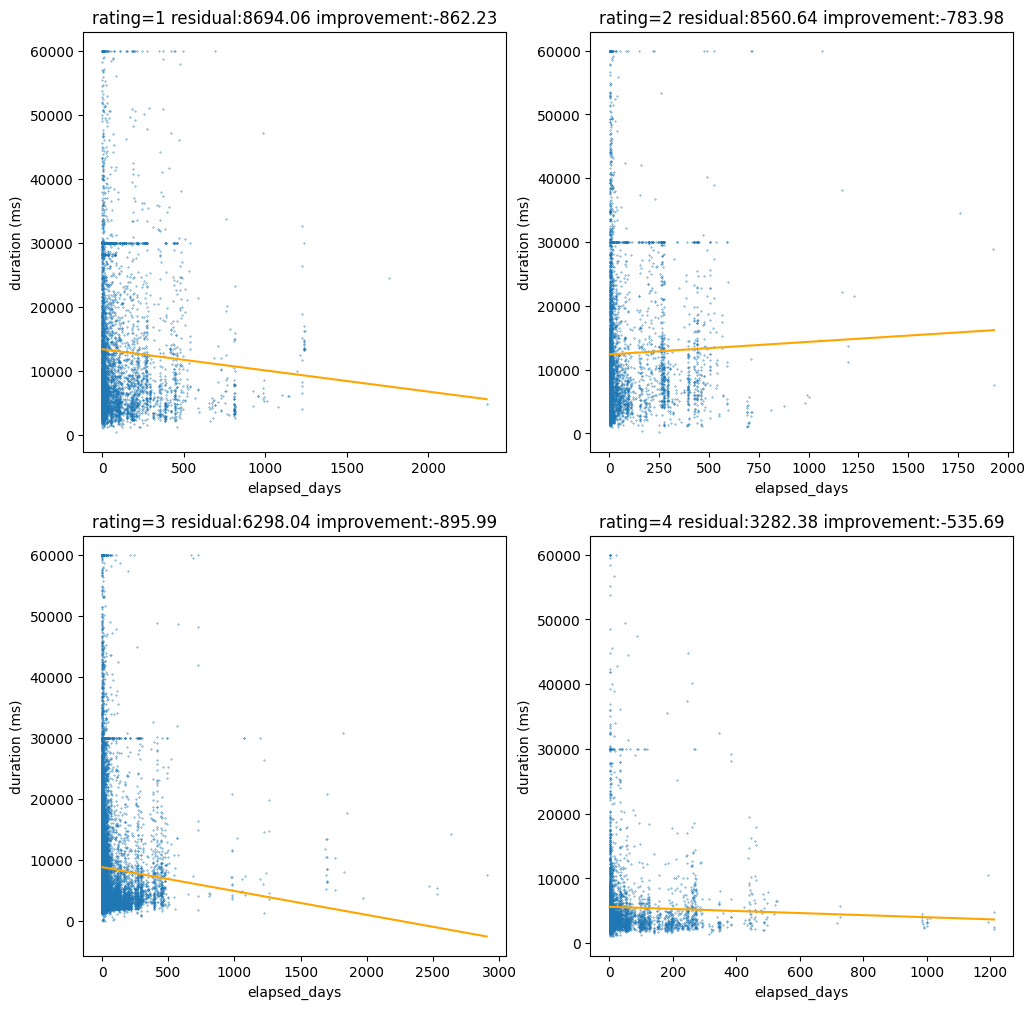

In [14]:
duration_plot_ratings("elapsed_days")

/tmp/ipykernel_105714/246576057.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(x_col, inplace=True)


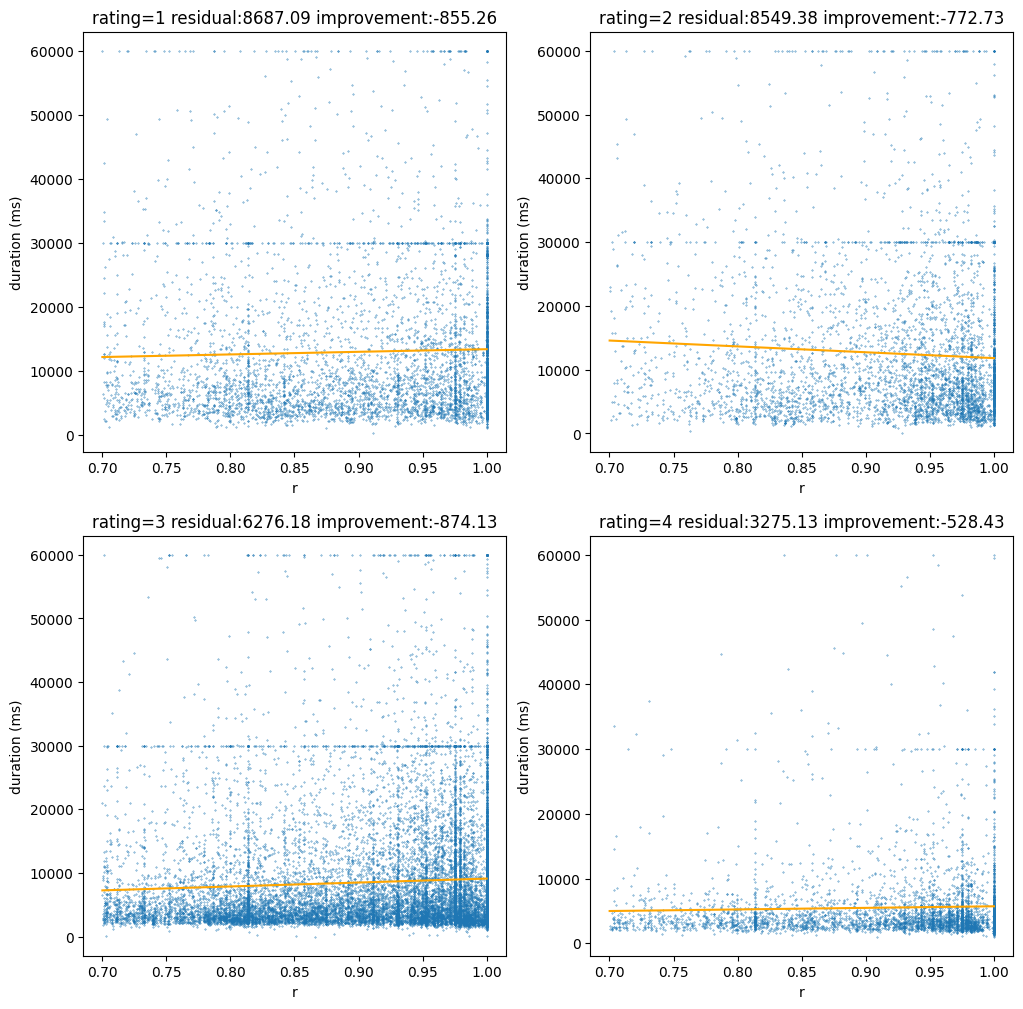

In [15]:
duration_plot_ratings("r")

/tmp/ipykernel_105714/246576057.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(x_col, inplace=True)


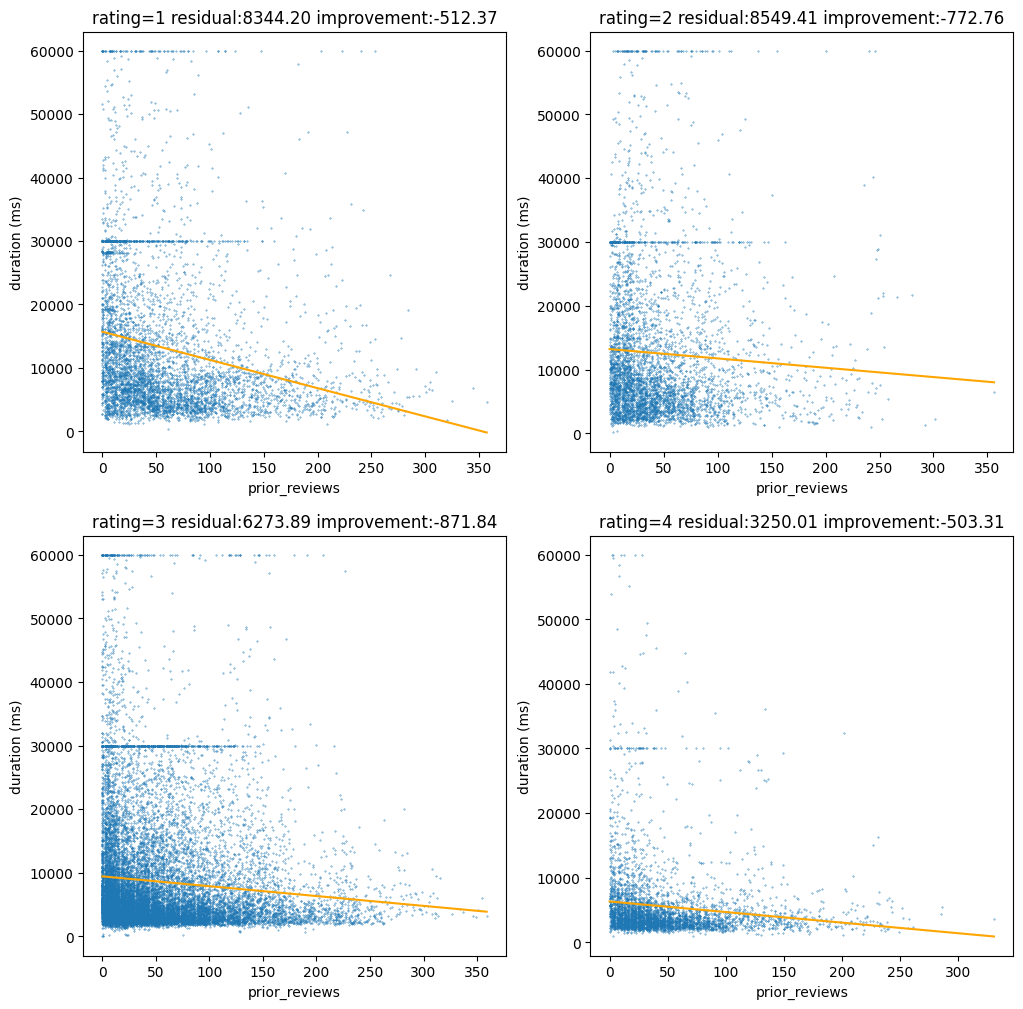

In [16]:
df["prior_reviews"] = df.groupby("day_offset").cumcount()
duration_plot_ratings("prior_reviews")